# Vertical Velocity Regression Cross-Sections (DJF-anchored against Nino3.4)

This notebook builds time–vertical regression cross-sections of ERA5 vertical velocity (w) against the DJF Niño 3.4 index.
Intermediate data are cached, and output figures are saved in results/1_Revisi.

## 1. Imports and settings

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import t as student_t

plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 16,
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.titleweight': 'regular',
    'figure.dpi': 150,
})

SCRIPT_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/LaggedRegression')
DATA_DIR = SCRIPT_DIR if not (SCRIPT_DIR / 'data').exists() else (SCRIPT_DIR / 'data')
W_PATH = Path('/Users/rizzie/ClimateData/era5-monthly/vertical_velocity_1980-2025_1000hpa-100hpa.nc')
NINO34_PATH = Path('/Users/rizzie/ClimateData/index-monthly/nino34.anom.csv')
RESULTS_DIR = SCRIPT_DIR
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_BOX = {
    'lon_min': 95.0,
    'lon_max': 125.0,
    'lat_min': -6.0,
    'lat_max': 2.0,
}

P1_YEARS = np.arange(1981, 2007)
P2_YEARS = np.arange(2007, 2026)
SEASON_YEARS = np.arange(1981, 2026)

MONTH_SLOTS = [
    ('Jul(0)', 7, -1),
    ('Aug(0)', 8, -1),
    ('Sep(0)', 9, -1),
    ('Oct(0)', 10, -1),
    ('Nov(0)', 11, -1),
    ('Dec(0)', 12, -1),
    ('Jan(1)', 1, 0),
    ('Feb(1)', 2, 0),
]
SLOT_POS = np.arange(len(MONTH_SLOTS))
SLOT_LABELS = ['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']
PRESSURE_TICKS = [925, 850, 700, 500, 400, 300, 200, 100]
def contour_levels(start, stop, step):
    return np.round(np.arange(start, stop + step / 2, step), 10)

value_scale = 1e3
clevs = contour_levels(-10, 10.1, 0.5)
cticks = np.arange(-10, 10.1, 2)
cbar_ticks = np.arange(-10, 10.1, 2)


## 2. Load data

In [2]:
def open_w_dataset(path: Path) -> xr.Dataset:
    ds = xr.open_dataset(
        path,
        chunks={'time': 12, 'level': 1, 'lat': 181, 'lon': 360},
        decode_times=False,
    )
    ds = ds.drop_vars('step', errors='ignore')
    return xr.decode_cf(ds)


def load_nino34_series(path: Path) -> tuple[pd.Series, pd.Series]:
    df = pd.read_csv(path, parse_dates=['Date'])
    value_col = next(col for col in df.columns if col != 'Date')
    series = pd.to_numeric(df[value_col], errors='coerce').replace(-9999.0, np.nan)
    series = pd.Series(series.to_numpy(), index=df['Date'], name='nino34').sort_index()
    series = series.loc['1980-01-01':'2025-12-01'].copy()
    series_3mo = series.rolling(3, center=True, min_periods=3).mean()
    return series, series_3mo


def build_centered_3mo_running_mean(series: pd.Series) -> pd.Series:
    return series.rolling(3, center=True, min_periods=3).mean().dropna()


def monthly_anomaly(da: xr.DataArray, base_start: str, base_end: str) -> xr.DataArray:
    base = da.sel(time=slice(base_start, base_end))
    monthly_mean = base.groupby('time.month').mean('time')
    return da.groupby('time.month') - monthly_mean




def standardize_series(series: pd.Series) -> pd.Series:
    series = pd.Series(series.copy(), index=series.index, name=series.name)
    mean = series.mean(skipna=True)
    std = series.std(ddof=0, skipna=True)
    if std == 0 or not np.isfinite(std):
        return series * np.nan
    return (series - mean) / std


def standardize_series_over_period(series: pd.Series, base_start: str, base_end: str) -> pd.Series:
    base = series.loc[base_start:base_end]
    if len(base) == 0:
        raise ValueError('No data found in the requested climatology window')
    mean = base.mean(skipna=True)
    std = base.std(ddof=0, skipna=True)
    if std == 0 or not np.isfinite(std):
        raise ValueError('Climatology standard deviation is zero or NaN')
    standardized = (series - mean) / std
    return pd.Series(standardized.to_numpy(), index=series.index, name=series.name)


def standardize_series_over_years(series: pd.Series, base_years: np.ndarray) -> pd.Series:
    base = series.loc[base_years]
    if len(base) == 0:
        raise ValueError('No data found in the requested climatology years')
    mean = base.mean(skipna=True)
    std = base.std(ddof=0, skipna=True)
    if std == 0 or not np.isfinite(std):
        raise ValueError('Climatology standard deviation is zero or NaN')
    standardized = (series - mean) / std
    return pd.Series(standardized.to_numpy(), index=series.index, name=series.name)


def build_djf_index(nino_raw: pd.Series, years: np.ndarray) -> pd.Series:
    values = []
    for year in years:
        dec = pd.Timestamp(year - 1, 12, 1)
        jan = pd.Timestamp(year, 1, 1)
        feb = pd.Timestamp(year, 2, 1)
        values.append(np.nanmean([nino_raw.loc[dec], nino_raw.loc[jan], nino_raw.loc[feb]]))
    return pd.Series(values, index=years, name='nino_djf')




def standardize_da_over_dim(da: xr.DataArray, dim: str) -> xr.DataArray:
    mean = da.mean(dim, skipna=True)
    std = da.std(dim, skipna=True)
    std = xr.where(std == 0, np.nan, std)
    return (da - mean) / std


def _finite_mask(*arrays):
    mask = None
    for arr in arrays:
        current = xr.apply_ufunc(np.isfinite, arr, dask='parallelized', output_dtypes=[bool])
        mask = current if mask is None else (mask & current)
    return mask


def simple_regression_stats(field, index, sample_dim):
    field, index = xr.align(field, index, join='inner')
    valid = _finite_mask(field, index)
    x = index.where(valid)
    y = field.where(valid)

    n = valid.sum(sample_dim).astype(np.float32)
    safe_n = xr.where(n > 0, n, np.nan)

    sx = x.sum(sample_dim, skipna=True)
    sy = y.sum(sample_dim, skipna=True)
    sxx = (x * x).sum(sample_dim, skipna=True)
    syy = (y * y).sum(sample_dim, skipna=True)
    sxy = (x * y).sum(sample_dim, skipna=True)

    sxx_c = sxx - (sx ** 2 / safe_n)
    sxy_c = sxy - (sx * sy / safe_n)
    syy_c = syy - (sy ** 2 / safe_n)

    slope = sxy_c / sxx_c
    df = safe_n - 2
    sse = syy_c - (sxy_c ** 2 / sxx_c)
    mse = sse / df
    se = np.sqrt(mse / sxx_c)
    t_stat = slope / se
    p = xr.apply_ufunc(
        lambda t, dof: 2 * student_t.sf(np.abs(t), df=dof),
        t_stat,
        df,
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float],
    )

    valid_stats = (n >= 3) & np.isfinite(slope) & np.isfinite(p)
    slope = slope.where(valid_stats)
    p = p.where(valid_stats)
    return slope.astype(np.float32), p.astype(np.float32), n


def pooled_ols_interaction_stats(field_past, field_recent, index_past, index_recent, sample_dim):
    field_past, index_past = xr.align(field_past, index_past, join='inner')
    field_recent, index_recent = xr.align(field_recent, index_recent, join='inner')

    valid_past = _finite_mask(field_past, index_past)
    valid_recent = _finite_mask(field_recent, index_recent)

    y0 = field_past.where(valid_past)
    x0 = index_past.where(valid_past)
    y1 = field_recent.where(valid_recent)
    x1 = index_recent.where(valid_recent)

    def _pooled_ols_1d(y0, x0, y1, x1):
        y0 = np.asarray(y0, dtype=float)
        x0 = np.asarray(x0, dtype=float)
        y1 = np.asarray(y1, dtype=float)
        x1 = np.asarray(x1, dtype=float)

        valid0 = np.isfinite(y0) & np.isfinite(x0)
        valid1 = np.isfinite(y1) & np.isfinite(x1)
        y = np.concatenate([y0[valid0], y1[valid1]])
        x = np.concatenate([x0[valid0], x1[valid1]])
        d = np.concatenate([
            np.zeros(valid0.sum(), dtype=float),
            np.ones(valid1.sum(), dtype=float),
        ])

        n = y.size
        if n < 4:
            return np.nan, np.nan, np.nan

        X = np.column_stack([np.ones(n), x, d, x * d])
        try:
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            resid = y - X @ beta
            rss = float(np.sum(resid ** 2))
            df = float(n - X.shape[1])
            if df <= 0:
                return np.nan, np.nan, df
            xtx_inv = np.linalg.inv(X.T @ X)
            sigma2 = rss / df
            se = float(np.sqrt(sigma2 * xtx_inv[3, 3]))
            diff = float(beta[3])
            if not np.isfinite(diff) or not np.isfinite(se) or se == 0:
                return np.nan, np.nan, df
            t_stat = diff / se
            p = float(2 * student_t.sf(np.abs(t_stat), df=df))
            return diff, p, df
        except np.linalg.LinAlgError:
            return np.nan, np.nan, np.nan

    diff, p, df = xr.apply_ufunc(
        _pooled_ols_1d,
        y0,
        x0,
        y1,
        x1,
        input_core_dims=[[sample_dim], [sample_dim], [sample_dim], [sample_dim]],
        output_core_dims=[[], [], []],
        join='override',
        exclude_dims={sample_dim},
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float, float],
        dask_gufunc_kwargs={'allow_rechunk': True},
    )
    return diff.astype(np.float32), p.astype(np.float32), df.astype(np.float32)


def season_window_date(year: int, month: int, year_shift: int) -> pd.Timestamp:
    return pd.Timestamp(year + year_shift, month, 1)


def build_window_cube(
    w_anom: xr.DataArray,
    nino_centered_3mo: pd.Series,
    nino_djf: pd.Series,
    years: np.ndarray,
) -> tuple[xr.DataArray, xr.DataArray, xr.DataArray]:
    w_rows = []
    nino_sim_rows = []
    nino_djf_rows = []

    for year in years:
        w_slots = []
        sim_slots = []
        djf_slots = []
        for _, month, year_shift in MONTH_SLOTS:
            date = season_window_date(year, month, year_shift)
            w_slots.append(w_anom.sel(time=date).values)
            sim_slots.append(float(nino_centered_3mo.loc[date]))
            djf_slots.append(float(nino_djf.loc[year]))
        w_rows.append(np.stack(w_slots, axis=0))
        nino_sim_rows.append(np.array(sim_slots, dtype=float))
        nino_djf_rows.append(np.array(djf_slots, dtype=float))

    w_cube = xr.DataArray(
        np.stack(w_rows, axis=0),
        coords={'season_year': years, 'slot': SLOT_POS, 'level': w_anom['level'].values},
        dims=('season_year', 'slot', 'level'),
        name='w_anom_cube',
    )
    nino_sim_cube = xr.DataArray(
        np.stack(nino_sim_rows, axis=0),
        coords={'season_year': years, 'slot': SLOT_POS},
        dims=('season_year', 'slot'),
        name='nino_centered_3mo',
    )
    nino_djf_cube = xr.DataArray(
        np.stack(nino_djf_rows, axis=0),
        coords={'season_year': years, 'slot': SLOT_POS},
        dims=('season_year', 'slot'),
        name='nino_djf',
    )
    return w_cube, nino_sim_cube, nino_djf_cube




def reg_by_slot_level(q_cube: xr.DataArray, nino_cube: xr.DataArray) -> tuple[xr.DataArray, xr.DataArray, xr.DataArray]:
    slope, p, n = simple_regression_stats(q_cube, nino_cube, 'season_year')
    return slope, p, n


def plot_cross_section(ax, da: xr.DataArray, title: str, *, clevs, cticks, value_scale=1.0, cmap_name='bwr', white_band=(-1.0, 1.0)):
    plot_values = da.transpose('level', 'slot').values * value_scale
    from matplotlib.colors import ListedColormap
    plot_cmap = cmap_name
    levels = np.asarray(clevs)
    if white_band is not None:
        white_low, white_high = white_band
        colors = plt.get_cmap(cmap_name, len(levels) - 1)(np.linspace(0, 1, len(levels) - 1))
        band_mask = (levels[:-1] >= white_low) & (levels[1:] <= white_high)
        colors[band_mask] = np.array([1, 1, 1, 1])
        plot_cmap = ListedColormap(colors)
    mesh = ax.contourf(
        da['slot'].values,
        da['level'].values,
        plot_values,
        levels=clevs,
        cmap=plot_cmap,
        extend='both',
    )
    ax.contour(
        da['slot'].values,
        da['level'].values,
        plot_values,
        levels=cticks,
        colors='k',
        linewidths=0.5,
        alpha=0.45,
    )
    ax.set_title(title, loc='left', fontsize=18, fontweight='bold', pad=22)
    ax.set_xticks(SLOT_POS)
    ax.set_xticklabels(SLOT_LABELS)
    ax.set_xlabel('Month', fontsize=16, labelpad=10)
    ax.set_ylim(float(da['level'].max()), float(da['level'].min()))
    ax.set_yticks(PRESSURE_TICKS)
    ax.set_yticklabels([str(int(v)) for v in PRESSURE_TICKS])
    ax.set_ylabel('Pressure level (hPa)', fontsize=16, labelpad=12)
    ax.tick_params(axis='both', labelsize=16)
    return mesh


In [3]:
cache_file = DATA_DIR / 'omega_reg.nc' if (DATA_DIR / 'omega_reg.nc').exists() else DATA_DIR / 'gambarL.8_omega_reg.nc'

if cache_file.exists():
    print("Loading regression data from intermediate cache:", cache_file)
    ds_reg = xr.open_dataset(cache_file)
    reg_djf_p1 = ds_reg['reg_djf_p1']
    reg_djf_p2 = ds_reg['reg_djf_p2']
    reg_djf_delta = ds_reg['reg_djf_delta']
    reg_djf_p1_p = ds_reg['reg_djf_p1_p']
    reg_djf_p2_p = ds_reg['reg_djf_p2_p']
    reg_djf_delta_p = ds_reg['reg_djf_delta_p']
else:
    print("Intermediate cache not found. Building regression data...")
    w_ds = open_w_dataset(W_PATH)
    w_box = w_ds['w'].sel(lat=slice(2, -6), lon=slice(95, 125))
    lat_weights = np.cos(np.deg2rad(w_box['lat']))
    w_region_mean = w_box.weighted(lat_weights).mean(('lat', 'lon'))
    w_anom = monthly_anomaly(w_region_mean, '1981-01-01', '2025-12-31').load()

    nino_raw, _ = load_nino34_series(NINO34_PATH)
    nino_centered_3mo = build_centered_3mo_running_mean(nino_raw)
    nino_centered_3mo = standardize_series_over_period(nino_centered_3mo, '1981-01-01', '2025-12-01')
    nino_djf = build_djf_index(nino_raw, SEASON_YEARS)
    nino_djf = standardize_series_over_years(nino_djf, np.arange(1981, 2026))
    
    w_cube_p1, _, nino_djf_p1 = build_window_cube(w_anom, nino_centered_3mo, nino_djf, P1_YEARS)
    w_cube_p2, _, nino_djf_p2 = build_window_cube(w_anom, nino_centered_3mo, nino_djf, P2_YEARS)
    
    reg_djf_p1, reg_djf_p1_p, _ = reg_by_slot_level(w_cube_p1, nino_djf_p1)
    reg_djf_p2, reg_djf_p2_p, _ = reg_by_slot_level(w_cube_p2, nino_djf_p2)
    reg_djf_delta, reg_djf_delta_p, _ = pooled_ols_interaction_stats(w_cube_p1, w_cube_p2, nino_djf_p1, nino_djf_p2, 'season_year')
    
    # Save to intermediate
    ds_reg = xr.Dataset({
        'reg_djf_p1': reg_djf_p1,
        'reg_djf_p2': reg_djf_p2,
        'reg_djf_delta': reg_djf_delta,
        'reg_djf_p1_p': reg_djf_p1_p,
        'reg_djf_p2_p': reg_djf_p2_p,
        'reg_djf_delta_p': reg_djf_delta_p
    })
    cache_file.parent.mkdir(parents=True, exist_ok=True)
    ds_reg.to_netcdf(cache_file)
    print("Regression data built and saved to intermediate cache successfully.")


Loading regression data from intermediate cache: /Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/LaggedRegression/omega_reg.nc


## 3. Sanity check and regression cubes

In [4]:
print('DJF-anchored P1 shape:', reg_djf_p1.shape)
print('DJF-anchored P2 shape:', reg_djf_p2.shape)
print('DJF-anchored delta shape:', reg_djf_delta.shape)


DJF-anchored P1 shape: (8, 12)
DJF-anchored P2 shape: (8, 12)
DJF-anchored delta shape: (8, 12)


## 5. Plot DJF-anchored regression

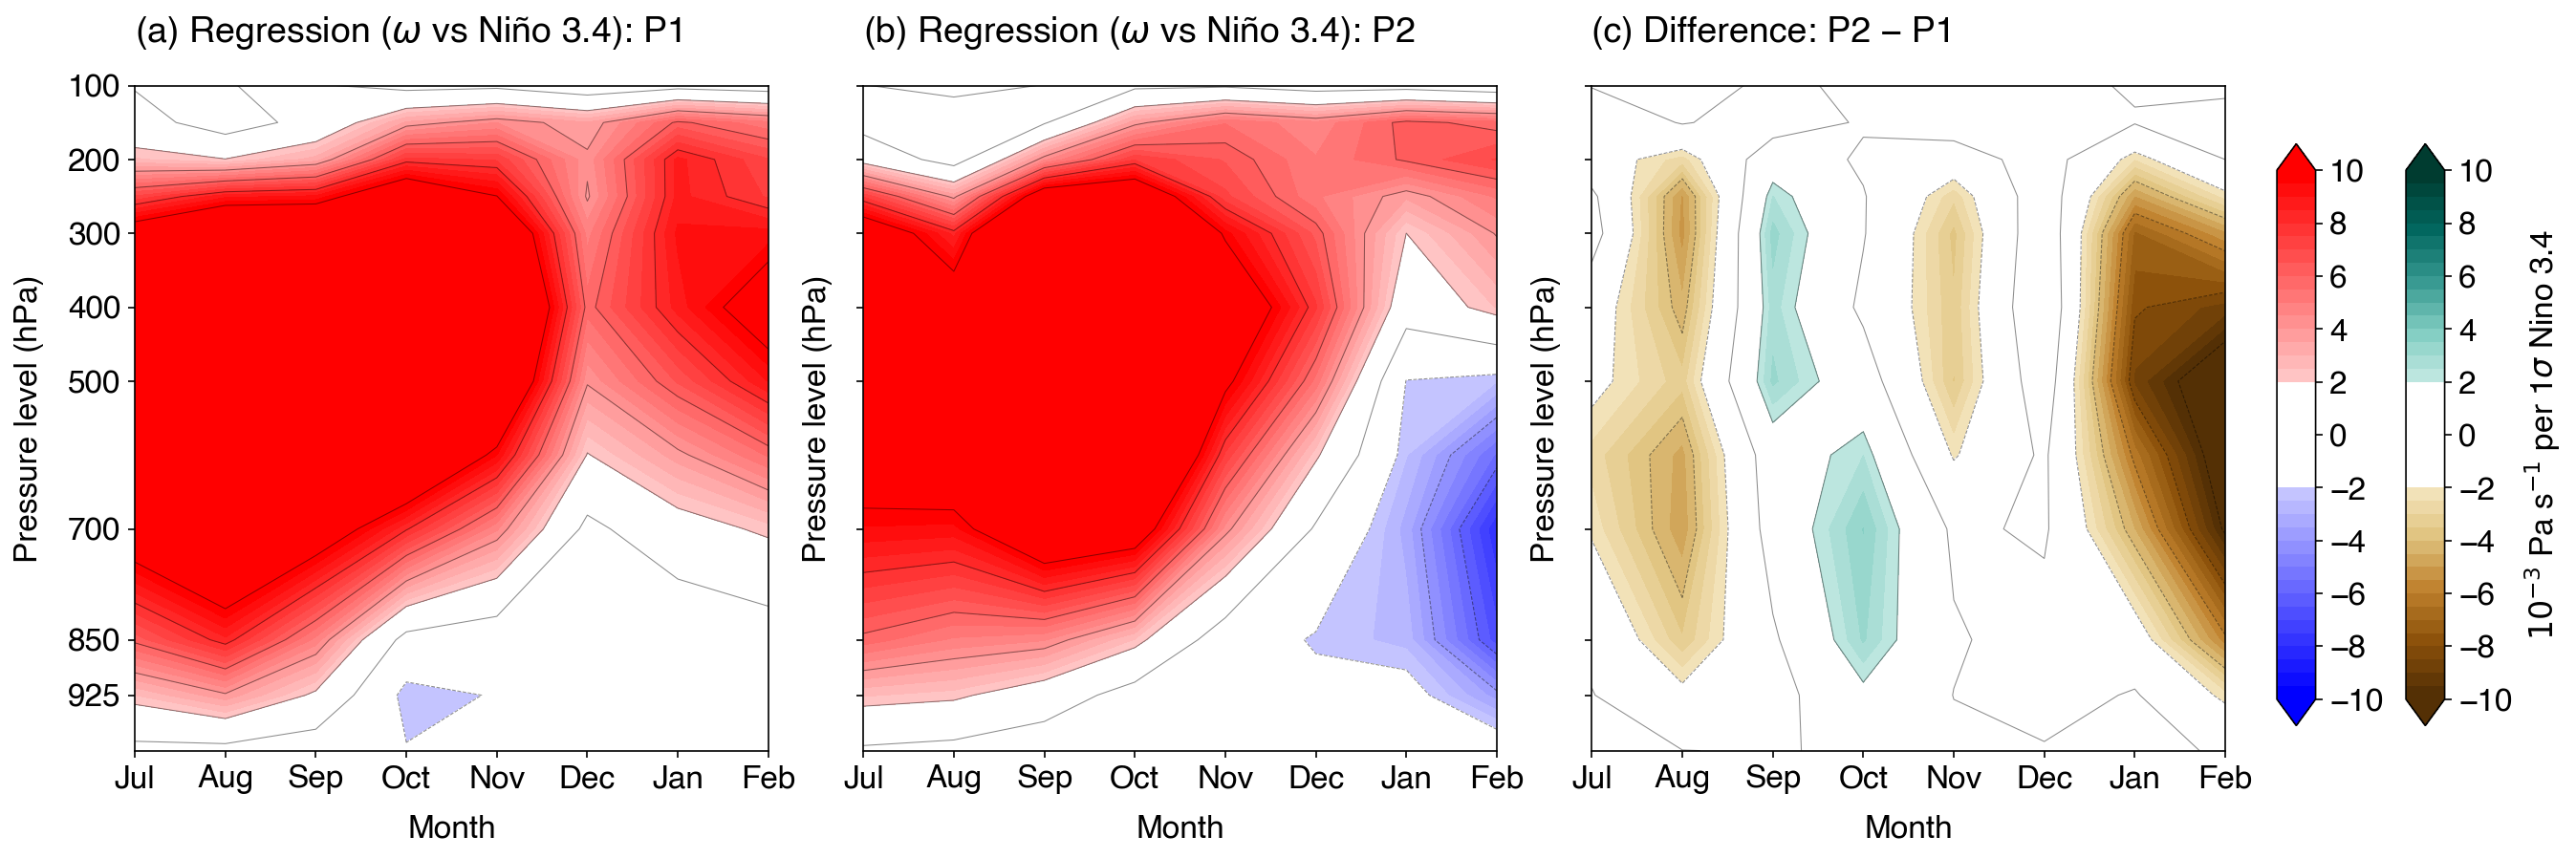

In [5]:
panel_specs = [
    (reg_djf_p1, r'(a) Regression ($\omega$ vs Niño 3.4): P1'),
    (reg_djf_p2, r'(b) Regression ($\omega$ vs Niño 3.4): P2'),
    (reg_djf_delta, r'(c) Difference: P2 − P1'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharey=True)
fig.subplots_adjust(left=0.07, right=0.88, top=0.92, bottom=0.12, wspace=0.15)

mesh_bwr = None
mesh_delta = None
for ax, (da, title) in zip(axes, panel_specs):
    is_delta = da is reg_djf_delta
    cmap_name = 'BrBG' if is_delta else 'bwr'
    white_band = (-2.0, 2.0)
    mesh = plot_cross_section(ax, da, title, clevs=clevs, cticks=cticks, value_scale=value_scale, cmap_name=cmap_name, white_band=white_band)
    if is_delta:
        mesh_delta = mesh
    else:
        mesh_bwr = mesh

cbar_label = r'$10^{-3}$ Pa s$^{-1}$ per 1$\sigma$ Nino 3.4'
cbar_bwr_ax = fig.add_axes([0.900, 0.15, 0.015, 0.70])
cbar_bwr = fig.colorbar(mesh_bwr, cax=cbar_bwr_ax, ticks=cbar_ticks)
cbar_bwr.ax.yaxis.set_ticks_position('right')
cbar_bwr.ax.tick_params(labelsize=16, labelleft=False, labelright=True)

cbar_delta_ax = fig.add_axes([0.950, 0.15, 0.015, 0.70])
cbar_delta = fig.colorbar(mesh_delta, cax=cbar_delta_ax, ticks=cbar_ticks)
cbar_delta.ax.yaxis.set_ticks_position('right')
cbar_delta.ax.tick_params(labelsize=16, labelleft=False, labelright=True)
cbar_delta.ax.set_ylabel(cbar_label, fontsize=16, rotation=90, labelpad=5)
cbar_delta.ax.yaxis.set_label_position('right')

fig.savefig(RESULTS_DIR / 'lag_reg_omega.png', dpi=300, bbox_inches='tight')
plt.show()
